# Tutorial 4: Parameter sweeps of CPW and LOM designs


While the primary purpose of the **simpleLOMs** pacakge is to construct lumped models of superconducting devices, another aspect of this package is its ability to test a wide variety of device geometries at the circuit level, including the length, coupling, or the CPW cross-section. 

In this tutorial, we will see how to perform parameter sweeps of both `CPW` and lumped designs using `extract_f0_kappa` , `fit_lom`, and `resonator_readout_params`. By the end you will be able to sweep any device parameter of the network and extract a circuit that fits a desired design parameter.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import dataclasses
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf

import simpleLOMs as sl


# Shared simpleLOMs figure style — one identical look across every tutorial.
sl.apply_style()

cpw = sl.CPWParams(ep_r=11.45)                        # ultracold-silicon substrate
freq = rf.Frequency(4e9, 12e9, 8001, unit="Hz")
MODEL = "optimized"                                # best / default LOM


## Parameter sweeps with `measure_sweep`

`sl.measure_sweep(values, measure)` is a function to perform a parameter sweep for an
arbitrary knob in the design of a device, including geometry fields that are not `SweepConfig`
attributes. 

## Sweep 1: Resonator length sweep for frequency

The resonator length has a disproportionately large impact on the frequency of the CPW and as such it acts as the coarse frequency knob. 


In [3]:
d_values = np.linspace(5.5e-3, 9.0e-3, 6)          # 5.5 - 9.0 mm
r1 = sl.measure_sweep(d_values, lambda d: {"f0_GHz": sl.extract_f0_kappa(cpw, d=d, Cc=6e-15)[0] / 1e9})

for d, f in zip(r1["value"], r1["f0_GHz"]):
    print("d = {:.2f} mm    f0 = {:.4f} GHz".format(d * 1e3, f))


d = 5.50 mm    f0 = 10.5807 GHz
d = 6.20 mm    f0 = 9.4195 GHz
d = 6.90 mm    f0 = 8.4879 GHz
d = 7.60 mm    f0 = 7.7240 GHz
d = 8.30 mm    f0 = 7.0863 GHz
d = 9.00 mm    f0 = 6.5459 GHz


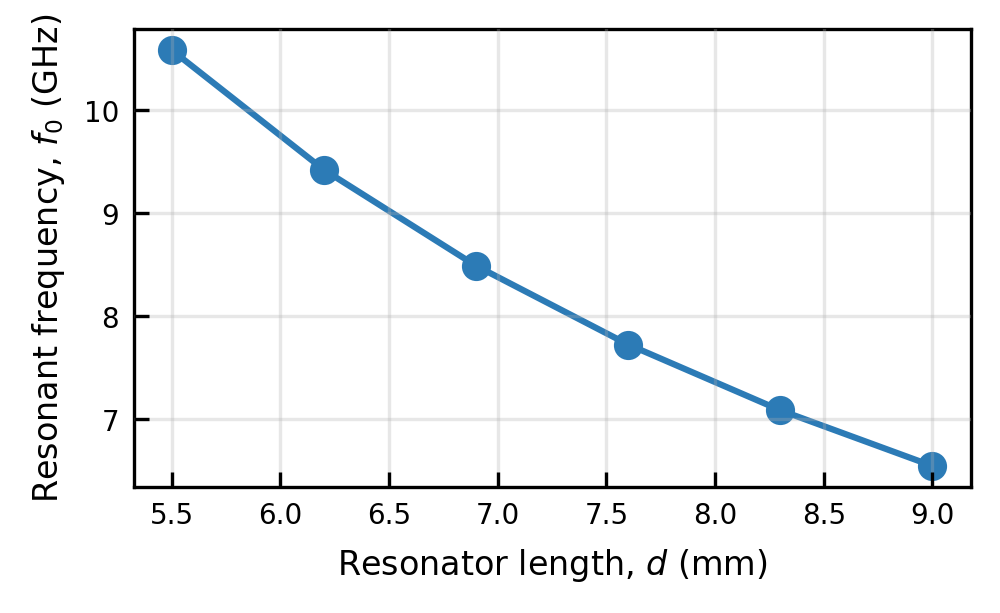

(<Figure size 1012.5x625.759 with 1 Axes>,
 <Axes: xlabel='Resonator length, $d$ (mm)', ylabel='Resonant frequency, $f_0$ (GHz)'>)

In [4]:
sl.plot_curves(
    r1["value"] * 1e3, r1["f0_GHz"],
    xlabel=sl.LABEL_LENGTH,
    ylabel=sl.LABEL_F0,
    fmt="o-",
    color=sl.COLOR_PRIMARY,
)


## Sweep 2: Coupling sweep for linewidth and $Q$

Once an approximate desired frequency has been reached, length may be kept fixed, and the user can now tune the coupling capacitor $C_c$ to change the linewidth. 


In [5]:
d0 = 7e-3
L, C = sl.fit_lom(d0, model=MODEL, cpw_params=cpw, freq=freq)   # one fit, reused below

def measure_coupling(Cc):
    f0, kappa = sl.extract_f0_kappa(cpw, d=d0, Cc=Cc)
    rp = sl.resonator_readout_params(L, C, kappa_Hz=kappa)
    return {"kappa_MHz": kappa / 1e6, "Q": rp.Q}

Cc_values = np.linspace(2e-15, 16e-15, 6)
r2 = sl.measure_sweep(Cc_values, measure_coupling)

for Cc, k, q in zip(r2["value"], r2["kappa_MHz"], r2["Q"]):
    print("Cc = {:4.1f} fF    kappa/2pi = {:7.3f} MHz    Q = {:8.0f}".format(Cc * 1e15, k, q))


Cc =  2.0 fF    kappa/2pi =   0.310 MHz    Q =    27259
Cc =  4.8 fF    kappa/2pi =   1.583 MHz    Q =     5339
Cc =  7.6 fF    kappa/2pi =   3.914 MHz    Q =     2160
Cc = 10.4 fF    kappa/2pi =   7.228 MHz    Q =     1169
Cc = 13.2 fF    kappa/2pi =  11.483 MHz    Q =      736
Cc = 16.0 fF    kappa/2pi =  16.636 MHz    Q =      508


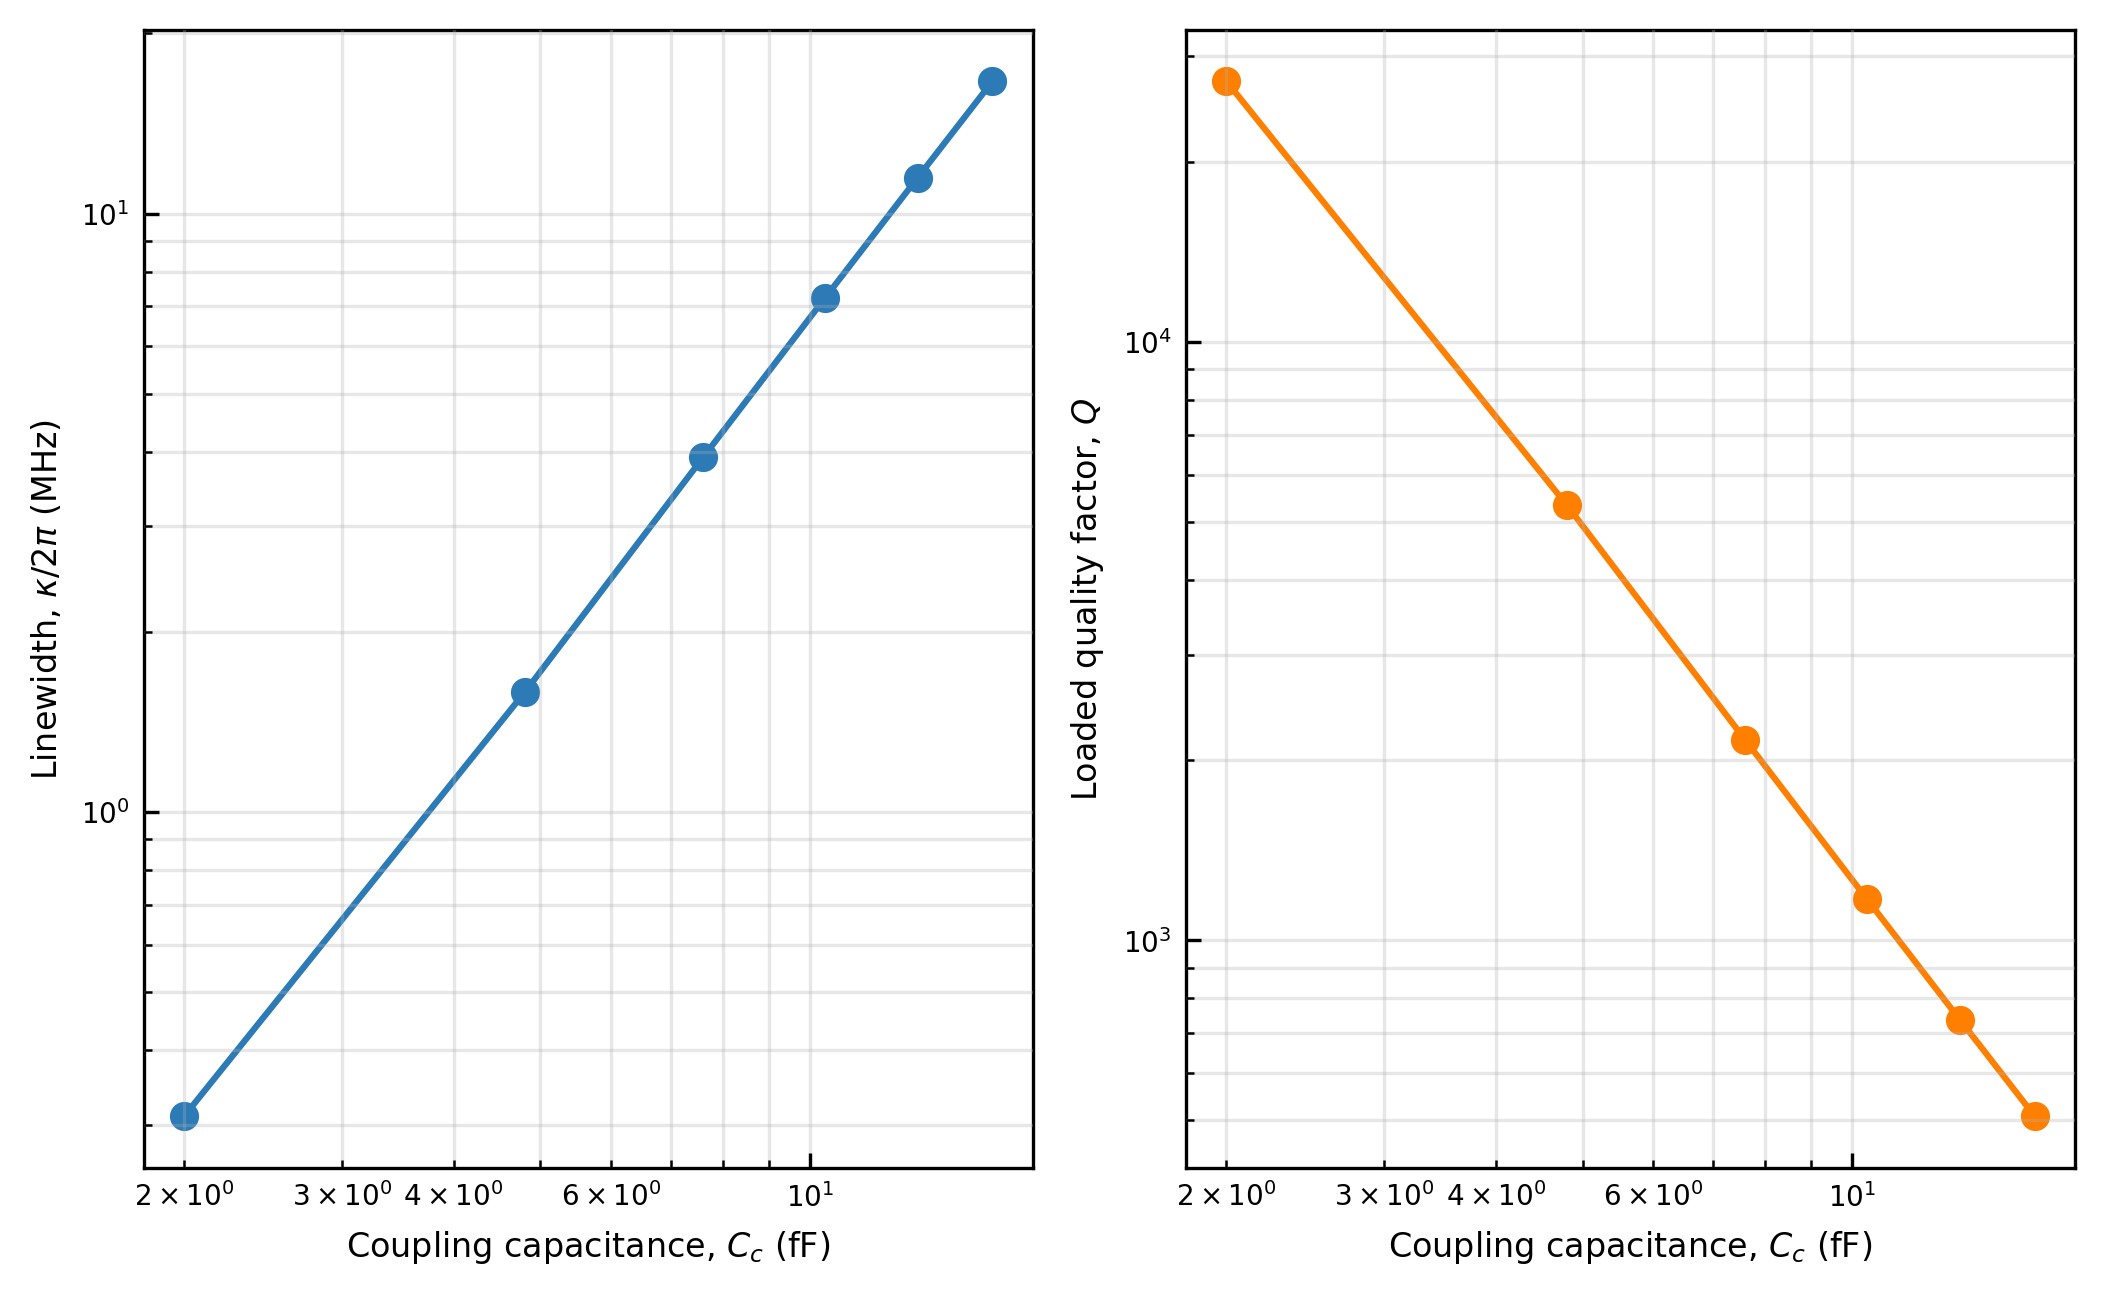

(<Figure size 2117.1x1308.44 with 2 Axes>,
 array([<Axes: xlabel='Coupling capacitance, $C_c$ (fF)', ylabel='Linewidth, $\\kappa/2\\pi$ (MHz)'>,
        <Axes: xlabel='Coupling capacitance, $C_c$ (fF)', ylabel='Loaded quality factor, $Q$'>],
       dtype=object))

In [6]:
sl.plot_curve_pair(
    r2["value"] * 1e15, r2["kappa_MHz"], r2["Q"],
    xlabel=sl.LABEL_CC,
    ylabel0=sl.LABEL_KAPPA,
    ylabel1=sl.axis_label("Loaded quality factor", "Q"),
    xscale="log", yscale="log",
)


## Sweep 3: CPW geometry sweep

The value to be swept in `measure_sweep` can be either a circuit value (like in the previous examples) or a physical
dimension. Here instead of sweeping a circuit value we instead sweep the CPW gap $s$ by swapping it into `CPWParams` with
`dataclasses.replace`, and measure the frequency the same way as Sweep 1.


s = 3.0 um    f0 = 8.3985 GHz
s = 4.2 um    f0 = 8.3808 GHz
s = 5.4 um    f0 = 8.3663 GHz
s = 6.6 um    f0 = 8.3538 GHz
s = 7.8 um    f0 = 8.3428 GHz
s = 9.0 um    f0 = 8.3330 GHz


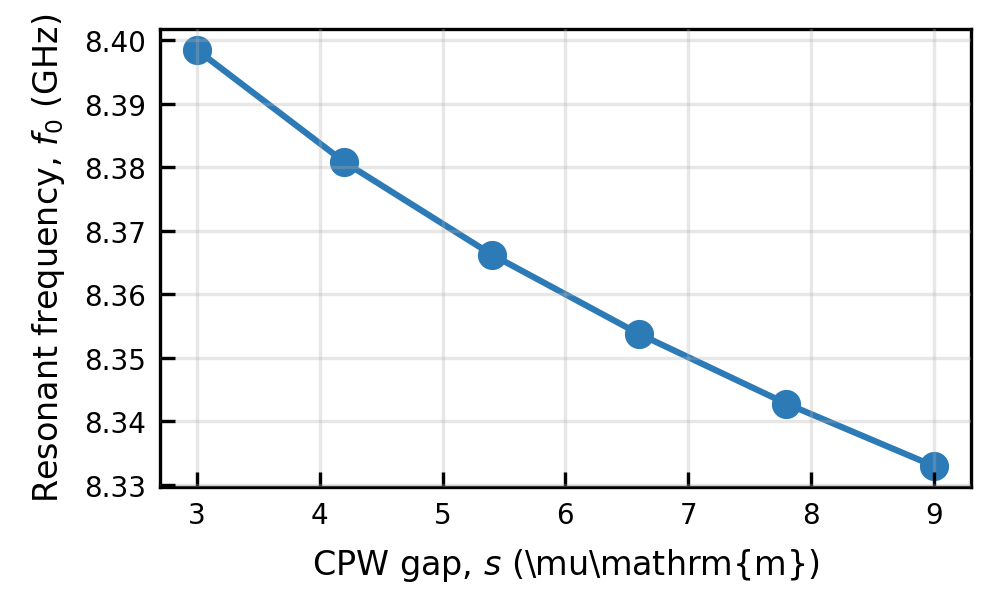

(<Figure size 1012.5x625.759 with 1 Axes>,
 <Axes: xlabel='CPW gap, $s$ (\\mu\\mathrm{m})', ylabel='Resonant frequency, $f_0$ (GHz)'>)

In [7]:
s_values = np.linspace(3e-6, 9e-6, 6)              # gap 3 - 9 um
r3 = sl.measure_sweep(s_values, lambda sg: {
    "f0_GHz": sl.extract_f0_kappa(dataclasses.replace(cpw, s=sg), d=7e-3, Cc=6e-15)[0] / 1e9})

for sg, f in zip(r3["value"], r3["f0_GHz"]):
    print("s = {:.1f} um    f0 = {:.4f} GHz".format(sg * 1e6, f))

sl.plot_curves(
    r3["value"] * 1e6, r3["f0_GHz"],
    xlabel=sl.LABEL_CPW_GAP,
    ylabel=sl.LABEL_F0,
    fmt="o-",
    color=sl.COLOR_PRIMARY,
)


The gap moves $f_0$ by only tens of MHz across this range, while the length
moved it by more than a GHz in Sweep 1.

In a similar fashion, other parameters of geometry can be swept to reach target design parameters such as a desired frequency, without having to perform finite-element simulations. This concept is explored further in **Tutorial 7**.